## Comparison between Unsupervised algorithms

In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline
import itertools
import warnings
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', RuntimeWarning)
warnings.simplefilter('ignore', UserWarning)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [109]:
# load files 
data = pd.read_csv('all_data_copy.csv', index_col=0)
data = data.replace('Carrier_to_ATL','ATL')
data = data.replace('Carrier_to_HAM','Carrier')

In [110]:
data.drop('Gag p19', axis=1, inplace=True)

In [111]:
df_copy = data.copy()

In [112]:
anomalous_indices_carrier = [
    'indiv0027', 'indiv0035', 'indiv0069', 'indiv0086', 'indiv0125',
    'indiv0131', 'indiv0133', 'indiv0169', 'indiv0189', 'indiv0217',
    'indiv0221', 'indiv0227', 'indiv0240', 'indiv0245', 'indiv0249',
    'indiv0254', 'indiv0265']

In [113]:
df_copy.loc[anomalous_indices_carrier, 'type'] = df_copy.loc[anomalous_indices_carrier, 'type'].replace('Carrier', 'Anomaly carrier')

In [114]:
IF_data = df_copy[df_copy['type'].isin(['Carrier', 'Anomaly carrier'])]
IF_data['type'] = IF_data['type'].replace({
    'Carrier': 'Normal',
    'Anomaly carrier': 'Anomaly'})

/var/folders/_4/p4p8llrs7s97qrcpyfmwrnx00000gn/T/ipykernel_89141/775521226.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IF_data['type'] = IF_data['type'].replace({


In [115]:
IF_data = IF_data.rename(columns={'type': 'IF_Anomaly_label'})

In [116]:
IF_data["IF_Anomaly_label"].value_counts()

IF_Anomaly_label
Normal     247
Anomaly     17
Name: count, dtype: int64

In [117]:
features = ['PVL', 'Tax', 'Env', 'Gag p15', 'Gag p24']

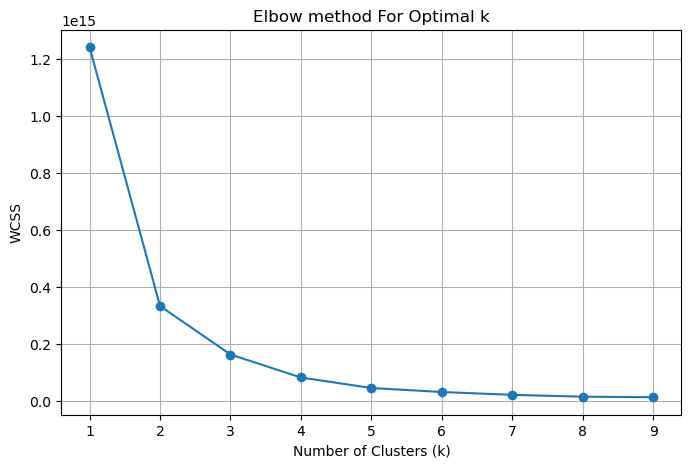

In [118]:
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(IF_data[features])
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [119]:
# K-Means Clustering (k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
IF_data['KMeans_Cluster'] = kmeans.fit_predict(IF_data[features])

# set smaller cluster as "Anomaly"
cluster_counts = IF_data['KMeans_Cluster'].value_counts()
anomaly_cluster = cluster_counts.idxmin()
IF_data['KMeans_Anomaly_label'] = ['Anomaly' if c == anomaly_cluster else 'Normal' for c in IF_data['KMeans_Cluster']]

In [120]:
IF_data["IF_Anomaly_label"].value_counts()

IF_Anomaly_label
Normal     247
Anomaly     17
Name: count, dtype: int64

In [121]:
from scipy.stats import mannwhitneyu

# Mann-Whitney U Tests + Bonferroni
results = []

for method in ['IF_Anomaly_label', 'KMeans_Anomaly_label']:
    for feature in features:
        group_anomaly = IF_data[IF_data[method] == 'Anomaly'][feature]
        group_normal = IF_data[IF_data[method] == 'Normal'][feature]
        stat, p = mannwhitneyu(group_anomaly, group_normal, alternative='two-sided')
        results.append({
            'Method': method.replace('_Anomaly_label', ''),
            'Feature': feature,
            'Raw_p_value': p
        })

# bonferroni correction
results_df = pd.DataFrame(results)
n_tests = len(results_df)
results_df['Bonferroni_p'] = results_df['Raw_p_value'] * n_tests
results_df['Bonferroni_p'] = results_df['Bonferroni_p'].apply(lambda x: min(x, 1.0))
results_df['Significant'] = results_df['Bonferroni_p'] < 0.05

print(results_df)

   Method  Feature  Raw_p_value  Bonferroni_p  Significant
0      IF      PVL        0.002         0.019         True
1      IF      Tax        0.000         0.000         True
2      IF      Env        0.000         0.000         True
3      IF  Gag p15        0.000         0.000         True
4      IF  Gag p24        0.000         0.000         True
5  KMeans      PVL        0.060         0.603        False
6  KMeans      Tax        0.009         0.090        False
7  KMeans      Env        0.000         0.000         True
8  KMeans  Gag p15        0.000         0.000         True
9  KMeans  Gag p24        0.000         0.000         True


In [122]:
iso_anomalies = set(IF_data[IF_data['IF_Anomaly_label'] == 'Anomaly'].index)
kmeans_anomalies = set(IF_data[IF_data['KMeans_Anomaly_label'] == 'Anomaly'].index)

# Calculating intersection and differences
both = iso_anomalies & kmeans_anomalies
only_iso = iso_anomalies - kmeans_anomalies
only_kmeans = kmeans_anomalies - iso_anomalies

print(f"Total IF anomalies: {len(iso_anomalies)}")
print(f"Total KMeans anomalies: {len(kmeans_anomalies)}")
print(f"Common anomalies: {len(both)}")
print(f"Only IF: {len(only_iso)}")
print(f"Only KMeans: {len(only_kmeans)}")

Total IF anomalies: 17
Total KMeans anomalies: 15
Common anomalies: 9
Only IF: 8
Only KMeans: 6


In [123]:
# comparison between anomalies of IF and Kmeans

if_anomalies = IF_data[IF_data['IF_Anomaly_label'] == 'Anomaly']
kmeans_anomalies = IF_data[IF_data['KMeans_Anomaly_label'] == 'Anomaly']

# Mann-whitney between IF and Kmeans anomaly sets
comparison_results = []

for feature in features:
    group_if = if_anomalies[feature]
    group_kmeans = kmeans_anomalies[feature]
    stat, p = mannwhitneyu(group_if, group_kmeans, alternative='two-sided')
    comparison_results.append({'Feature': feature, 'Raw_p_value': p})

# Bonferroni correction
results_df = pd.DataFrame(comparison_results)
results_df['Bonferroni_p'] = results_df['Raw_p_value'] * len(features)
results_df['Bonferroni_p'] = results_df['Bonferroni_p'].clip(upper=1.0)
results_df['Significant'] = results_df['Bonferroni_p'] < 0.05

print(results_df)

   Feature  Raw_p_value  Bonferroni_p  Significant
0      PVL        0.290         1.000        False
1      Tax        0.135         0.677        False
2      Env        0.835         1.000        False
3  Gag p15        0.748         1.000        False
4  Gag p24        0.192         0.961        False
